In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [54]:
df = pd.read_csv('height-weight.csv')

In [55]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


<Axes: xlabel='Weight', ylabel='Height'>

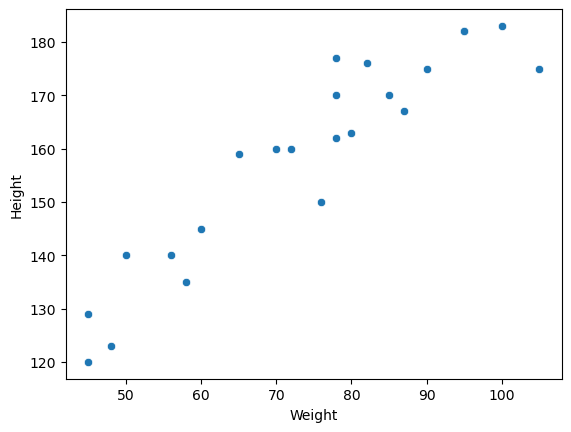

In [56]:
## Scatter Plot
sns.scatterplot(x=df['Weight'], y=df['Height'])

In [57]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [58]:
## Independent and dependent features

## Independent features should be data frame or 2 dimentional array
X = df[['Weight']]
print(type(X))

## Dependent feature should be one dimentional array or series
y = df['Height']
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [59]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Simple Linear Regression using OLS 

In [61]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [62]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
print("Coefficient or Slopt:", lr.coef_)
print("Intercept:", lr.intercept_)

Coefficient or Slopt: [17.03440872]
Intercept: 157.5


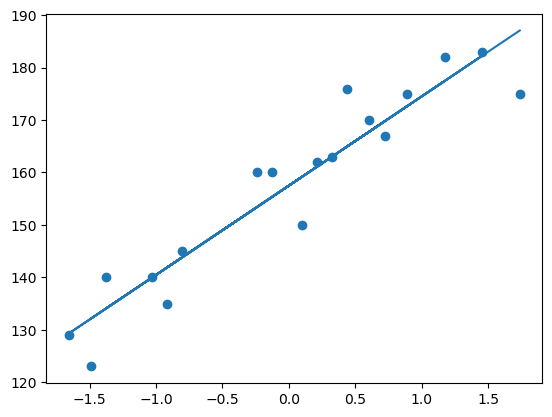

In [64]:
## Plot Training data plot best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train))

In [65]:
## Prediction for test data
y_pred = lr.predict(X_test)

In [66]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Mean Squared Error: 109.77592599051664
Mean Absolute Error: 9.822657814519232
Root Mean Squared Error: 10.477400726827081


In [67]:
## R2 Score
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)

0.776986986042344


In [68]:
## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]

adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(adjusted_score)

0.7026493147231252


## Simple Linear Regression using OLS 

In [69]:
import statsmodels.api as sm

model = sm.OLS(endog=y_train, exog=X_train).fit()

In [ ]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Mon, 13 Jul 2026   Prob (F-statistic):                       0.661
Time:                        13:46:11   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [71]:
prediction = model.predict(X_test)
print(prediction)

[  3.58467086   3.58467086 -28.1958439   19.95645118  -8.93492586]


In [72]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, prediction)
mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, prediction)
print(score)

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(adjusted_score)

Mean Squared Error: 26837.839468592294
Mean Absolute Error: 163.600995373339
Root Mean Squared Error: 163.82258534339
-53.521858176077316
-71.69581090143642


In [73]:
## Prdiction for new data
model.predict(scaler.transform([[72]]))

array([-2.19360455])

In [74]:
lr.predict(scaler.transform([[72]]))

array([155.30639545])